In [2]:
import torch
import torch.nn as nn
from torch.autograd import Variable
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np


cuda:0


In [3]:
# We consider Net as our solution u_theta(x,t)

"""
When forming the network, we have to keep in mind the number of inputs and outputs
In ur case: #inputs = 1 (x)
and #outputs = 1

You can add ass many hidden layers as you want with as many neurons.
More complex the network, the more prepared it is to find complex solutions, but it also requires more data.

Let us create this network:
min 5 hidden layer with 5 neurons each.
"""

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.hidden_layer1 = nn.Linear(1, 5)
        self.hidden_layer2 = nn.Linear(5, 5)
        self.hidden_layer3 = nn.Linear(5, 5)
        self.hidden_layer4 = nn.Linear(5, 5)
        self.hidden_layer5 = nn.Linear(5, 5)
        self.output_layer = nn.Linear(5, 1)

    def forward(self, x):
        #inputs = torch.cat([x,t],axis=1) # combined two arrays of 1 columns each to one array of 2 columns
        layer1_out = torch.sigmoid(self.hidden_layer1(x))
        layer2_out = torch.sigmoid(self.hidden_layer2(layer1_out))
        layer3_out = torch.sigmoid(self.hidden_layer3(layer2_out))
        layer4_out = torch.sigmoid(self.hidden_layer4(layer3_out))
        layer5_out = torch.sigmoid(self.hidden_layer5(layer4_out))
        output = self.output_layer(layer5_out) ## For regression, no activation is used in output layer
        return output

In [4]:
### (2) Model
net = Net()
net = net.to(device)

### Solve the following optimizaiton problem with PDE
$$
\min -y(x)\\

\textbf{s.t.} \frac{dy}{dx} + ay + by^2 + e \leq 0
$$

In [5]:
# pde constraint
def con(x, net, a=0.10, b=0.02, epsilon=0.01):
    y = net(x)
    dydx = torch.autograd.grad(y.sum(), x, create_graph=True)[0]
    return torch.max(torch.tensor(0.0, device=x.device), dydx + a * y + b * y * y + epsilon)

In [ ]:
### (3) Training / Fitting
# define pde parameters

a = 0.5
b = 0.1
epsilon = 0.01

# define optimizer
mse_cost_function = torch.nn.MSELoss() # Mean squared error
optimizer = torch.optim.Adam(net.parameters(), betas=(0.9, 0.999))

from tqdm import tqdm
# change the learing rate according to number of steps passed
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.7)

iterations = 20000
patience = 2000  # Number of epochs to wait before stopping if no improvement
best_loss = float('inf')
epochs_without_improvement = 0

net.train()
train_loss = []

# training domain
b0 = 0.0
b1 = 20.0
# number of sampling points in x traing domain
N_sample = 500

# pt_all_zeros = torch.from_numpy(all_zeros).float().to(device)
# pt_all_zeros.requires_grad = False

for epoch in tqdm(range(iterations)):
    optimizer.zero_grad() # to make the gradients zero

    # Loss based on ODE
    x_collocation = np.random.uniform(low=b0, high=b1, size=(N_sample,1)) # collocation points
    all_zeros = np.zeros((N_sample, 1))
    
    pt_x_collocation = torch.from_numpy(x_collocation).float().to(device)
    pt_x_collocation.requires_grad=True
    
    # pt_all_zeros = torch.from_numpy(all_zeros).float().to(device)
    # pt_all_zeros.requires_grad = False

    y_out = -net(pt_x_collocation) # cost value,
    con_out = con(pt_x_collocation, net, a=a, b=b, epsilon=epsilon) # constraints

    mse_f = y_out.sum() / N_sample
    mes_con = con_out.sum() / N_sample

    # Combining the loss functions
    loss = mse_f + 10.0 * mes_con

    loss.backward() # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to : theta_new = theta_old - alpha * derivative of J w.r.t theta

    # with torch.autograd.no_grad():
    train_loss.append(loss.item())
    
    # Learning rate update
    scheduler.step()
    
    # -------------------
    # Early Stopping Check
    # -------------------
    if loss.item() < best_loss:
        best_loss = loss.item()
        epochs_without_improvement = 0  # Reset counter
    else:
        epochs_without_improvement += 1
    
    # Stop training if no improvement for 'patience' epochs
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}. Best loss: {best_loss:.6f}")
        break  # Exit the training loop

# effective iterations
eff_itrs = epoch

  0%|          | 0/20000 [00:00<?, ?it/s]

100%|██████████| 20000/20000 [04:59<00:00, 66.87it/s]


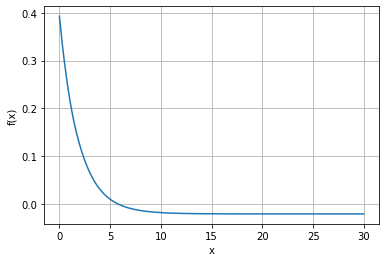

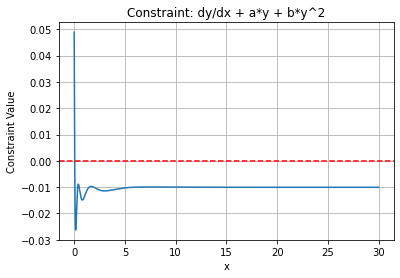

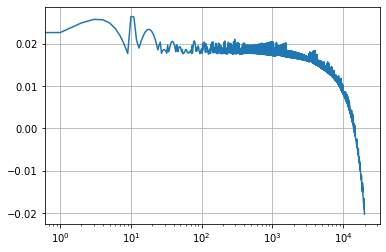

In [14]:
# evaluation
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np


net.eval()

# plot the figure of f(x)
x = np.arange(0, 30, 0.02).reshape(-1, 1)

pt_x = torch.from_numpy(x).float().to(device)
pt_x.requires_grad=True
# evaluation of the net
pt_u = net(pt_x)
# compute the graident
dy = torch.autograd.grad(pt_u, pt_x,  grad_outputs=torch.ones_like(pt_u), create_graph=True)[0]
# calculate constraint
dydx = dy + a * pt_u + b * pt_u * pt_u

u = pt_u.data.detach().cpu().numpy()
c = dydx.data.detach().cpu().numpy()

# plot the figure of f(x)
fig = plt.figure()
plt.plot(x, u)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
# plot the figure of dydx + a * y + b * y * y
fig = plt.figure()
plt.plot(x, c)
plt.axhline(0, color='red', linestyle='--', label="Zero Line")  # Dashed red line at zero
plt.title("Constraint: dy/dx + a*y + b*y^2")
plt.xlabel("x")
plt.ylabel("Constraint Value")
plt.grid(True)
# plot the figure of the training loss
fig = plt.figure()
plt.plot(range(0, eff_itrs + 1), train_loss)
plt.xscale('log')
plt.grid(True)